<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/Modelling_Polynomial_Regression_to_EEG_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Step 1: Import Libraries and Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns


In [ ]:
# 1. Load the data using the URL provided in the task instructions
url = "https://raw.githubusercontent.com/sijuswamy/A-modern-approach-to-Research/main/X.csv"
data = pd.read_csv(url)

# Extract features and target variable
x1 = data['x1'].values
x2 = data['x2'].values
y = data['y'].values
n = len(y)


##Step 2: Construct the Design Matrices for the 5 Models

##PRELIMINARY DATA ANALYSIS


Executing Task 1: Preliminary Data Analysis...


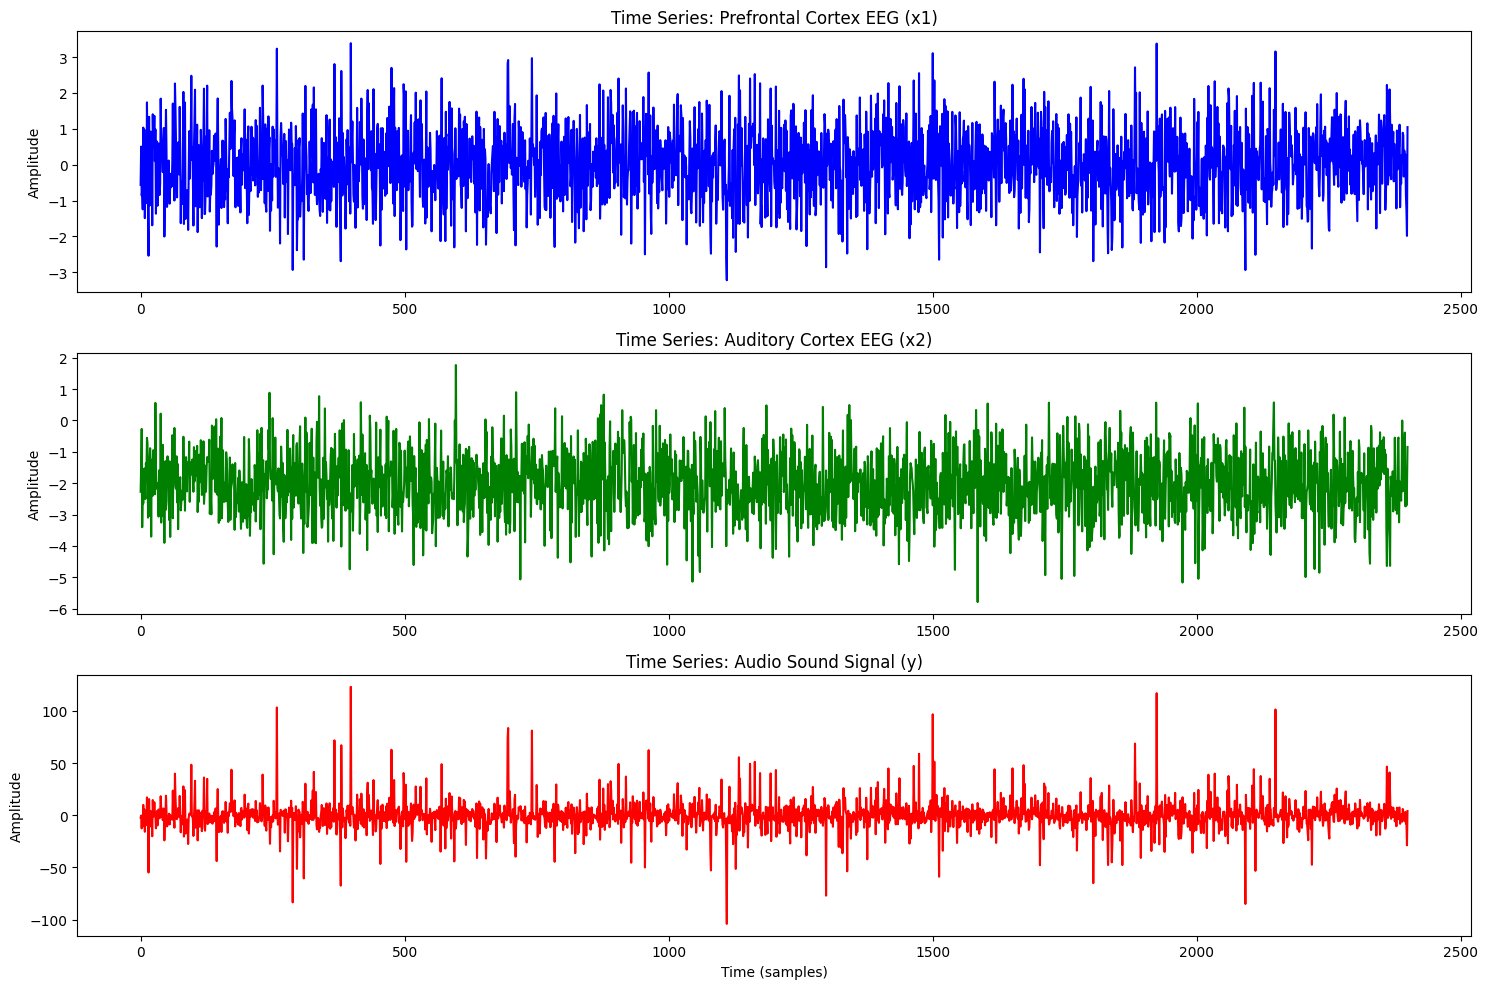

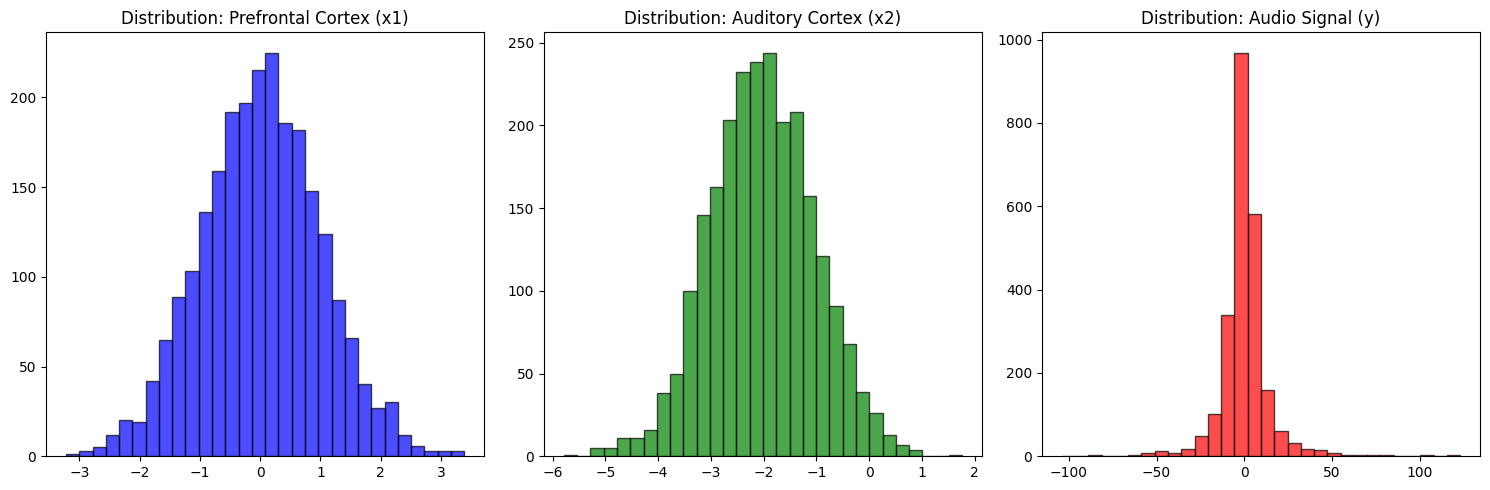

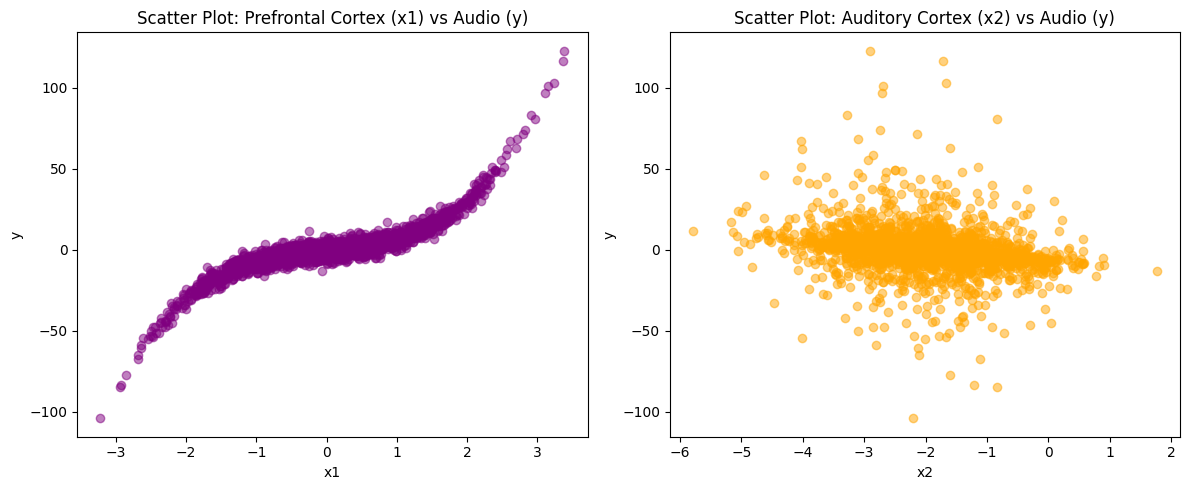


Correlation Matrix:
          x1        x2         y
x1  1.000000 -0.024313  0.862507
x2 -0.024313  1.000000 -0.252638
y   0.862507 -0.252638  1.000000


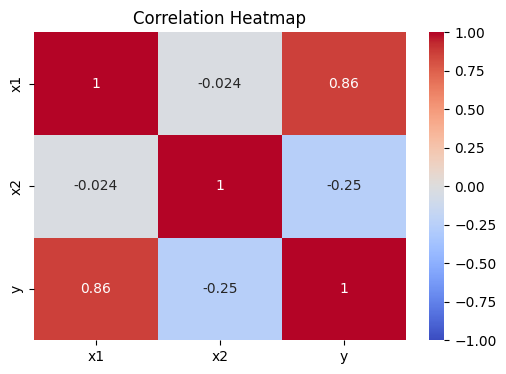

In [ ]:
print("\nExecuting Task 1: Preliminary Data Analysis...")

# --- 1. Time Series Plots ---
plt.figure(figsize=(15, 10))
plt.subplot(3, 1, 1)
plt.plot(data['x1'], color='blue')
plt.title('Time Series: Prefrontal Cortex EEG (x1)')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.plot(data['x2'], color='green')
plt.title('Time Series: Auditory Cortex EEG (x2)')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
plt.plot(data['y'], color='red')
plt.title('Time Series: Audio Sound Signal (y)')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# --- 2. Distribution Plots (Histograms) ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(data['x1'], bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Distribution: Prefrontal Cortex (x1)')

plt.subplot(1, 3, 2)
plt.hist(data['x2'], bins=30, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribution: Auditory Cortex (x2)')

plt.subplot(1, 3, 3)
plt.hist(data['y'], bins=30, color='red', edgecolor='black', alpha=0.7)
plt.title('Distribution: Audio Signal (y)')
plt.tight_layout()
plt.show()

# --- 3. Scatter Plots ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(data['x1'], data['y'], alpha=0.5, color='purple')
plt.title('Scatter Plot: Prefrontal Cortex (x1) vs Audio (y)')
plt.xlabel('x1')
plt.ylabel('y')

plt.subplot(1, 2, 2)
plt.scatter(data['x2'], data['y'], alpha=0.5, color='orange')
plt.title('Scatter Plot: Auditory Cortex (x2) vs Audio (y)')
plt.xlabel('x2')
plt.ylabel('y')
plt.tight_layout()
plt.show()

# --- 4. Correlation Analysis ---
correlation_matrix = data[['x1', 'x2', 'y']].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

##REGRESSION MODELLING

In [ ]:
# 2. Define the design matrices (X) for the 5 candidate models
# Model 1: y = 𝜃1*x1^3 + 𝜃2*x2^5 + 𝜃bias
X1 = pd.DataFrame({'x1_3': x1**3, 'x2_5': x2**5})

# Model 2: y = 𝜃1*x1^4 + 𝜃2*x2^2 + 𝜃bias
X2 = pd.DataFrame({'x1_4': x1**4, 'x2_2': x2**2})

# Model 3: y = 𝜃1*x1^3 + 𝜃2*x2 + 𝜃3*x1 + 𝜃bias
X3 = pd.DataFrame({'x1_3': x1**3, 'x2': x2, 'x1': x1})

# Model 4: y = 𝜃1*x1 + 𝜃2*x1^2 + 𝜃3*x1^3 + 𝜃4*x2^3 + 𝜃bias
X4 = pd.DataFrame({'x1': x1, 'x1_2': x1**2, 'x1_3': x1**3, 'x2_3': x2**3})

# Model 5: y = 𝜃1*x1^3 + 𝜃2*x1^4 + 𝜃3*x2 + 𝜃bias
X5 = pd.DataFrame({'x1_3': x1**3, 'x1_4': x1**4, 'x2': x2})

# Add a constant (bias/intercept) to all models
models = {
    "Model 1": sm.add_constant(X1),
    "Model 2": sm.add_constant(X2),
    "Model 3": sm.add_constant(X3),
    "Model 4": sm.add_constant(X4),
    "Model 5": sm.add_constant(X5)
}

##Step 3: Define a Function for Model Estimation and Metric Calculation

In [ ]:
def evaluate_model(model_name, X_df, y, n):
    print(f"\n{'='*40}\n{model_name}\n{'='*40}")

    # Task 2.1: OLS Regression using statsmodels [5]
    model_sm = sm.OLS(y, X_df).fit()
    print("--- Statsmodels Parameters ---")
    print(model_sm.params.values)

    # Task 2.1: Direct OLS with Matrix Method [5]
    X_mat = X_df.values
    theta_matrix = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y
    print("\n--- Matrix Method Parameters ---")
    print(theta_matrix)

    # Calculate predictions and residuals [5]
    y_pred = X_mat @ theta_matrix
    residuals = y - y_pred

    # Compute metrics: RSS, Log-likelihood, AIC, and BIC [5]
    rss = np.sum(residuals**2)

    # Correctly identify the number of parameters (k) using the number of columns
    k = X_mat.shape[1]

    variance_hat = rss / n
    log_likelihood = -(n/2)*np.log(2*np.pi) - (n/2)*np.log(variance_hat) - (1/(2*variance_hat))*rss
    aic = 2*k - 2*log_likelihood
    bic = k*np.log(n) - 2*log_likelihood

    print(f"\nRSS: {rss:.4f}")
    print(f"Log-Likelihood: {log_likelihood:.4f}")
    print(f"AIC: {aic:.4f}")
    print(f"BIC: {bic:.4f}")

    return residuals

##Step 4: Define a Function for Residual Distribution Analysis

In [ ]:
def plot_residuals(model_name, residuals):
    plt.figure(figsize=(10, 4))

    # Plot 1: Histogram of residuals
    plt.subplot(1, 2, 1)
    plt.hist(residuals, bins=30, edgecolor='black', density=True)
    plt.title(f'{model_name} - Residual Distribution')

    # Plot 2: Q-Q Plot
    plt.subplot(1, 2, 2)
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f'{model_name} - Q-Q Plot')

    plt.tight_layout()
    plt.show()

##Step 5: Execute the Analysis for All Candidate Models


Model 1
--- Statsmodels Parameters ---
[-1.14962247  3.59670957 -0.00588119]

--- Matrix Method Parameters ---
[-1.14962247  3.59670957 -0.00588119]

RSS: 30738.2205
Log-Likelihood: -6465.4982
AIC: 12936.9964
BIC: 12954.3461


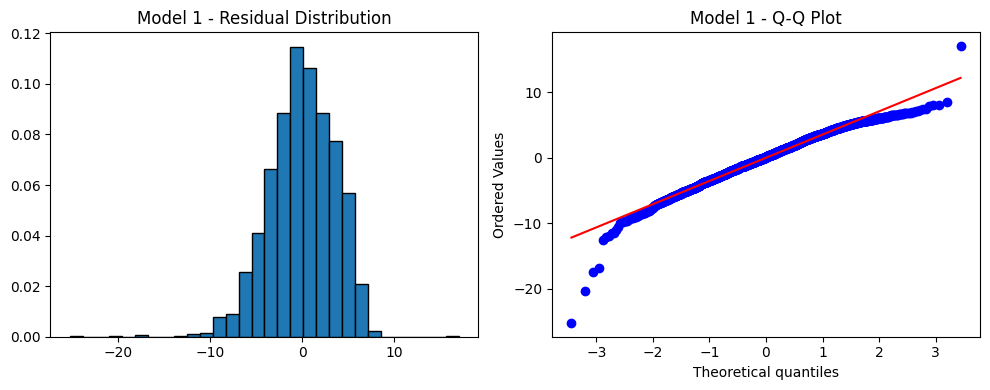


Model 2
--- Statsmodels Parameters ---
[-4.75196288  0.27432057  0.78316804]

--- Matrix Method Parameters ---
[-4.75196288  0.27432057  0.78316804]

RSS: 438230.3525
Log-Likelihood: -9654.1836
AIC: 19314.3672
BIC: 19331.7169


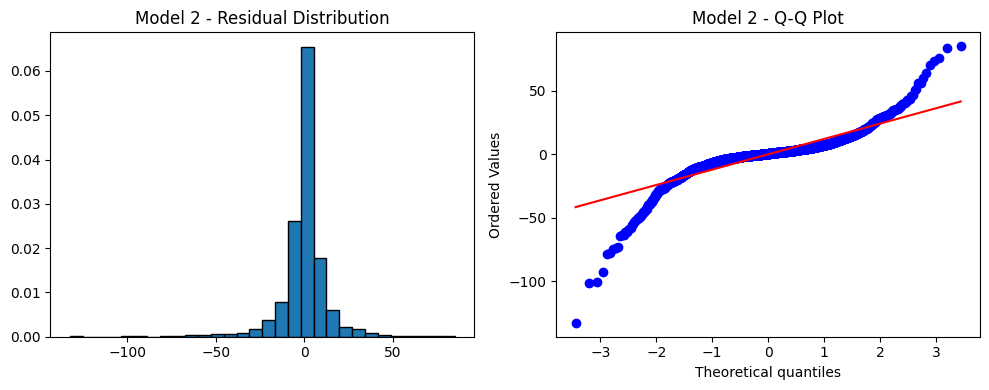


Model 3
--- Statsmodels Parameters ---
[-6.65140015  2.7157135  -3.15135043  4.1813899 ]

--- Matrix Method Parameters ---
[-6.65140015  2.7157135  -3.15135043  4.1813899 ]

RSS: 1525.6213
Log-Likelihood: -2861.7721
AIC: 5731.5442
BIC: 5754.6771


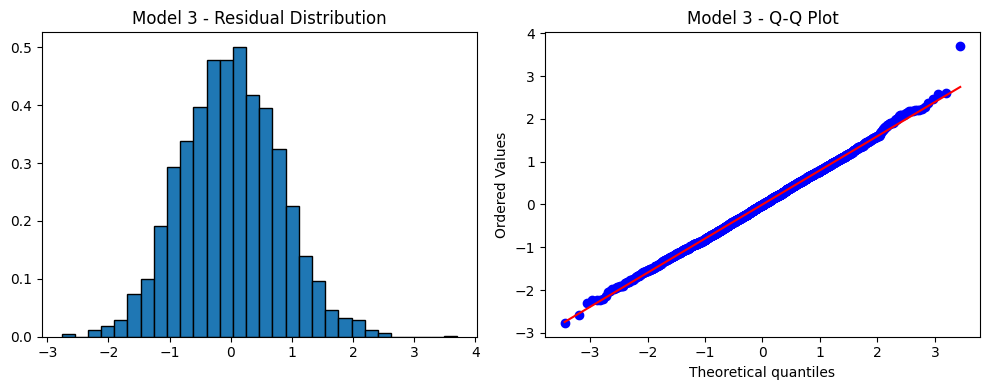


Model 4
--- Statsmodels Parameters ---
[-2.47404083  4.17136267  0.0594178   2.71900129 -0.14942085]

--- Matrix Method Parameters ---
[-2.47404083  4.17136267  0.0594178   2.71900129 -0.14942085]

RSS: 7949.2728
Log-Likelihood: -4842.5865
AIC: 9695.1731
BIC: 9724.0892


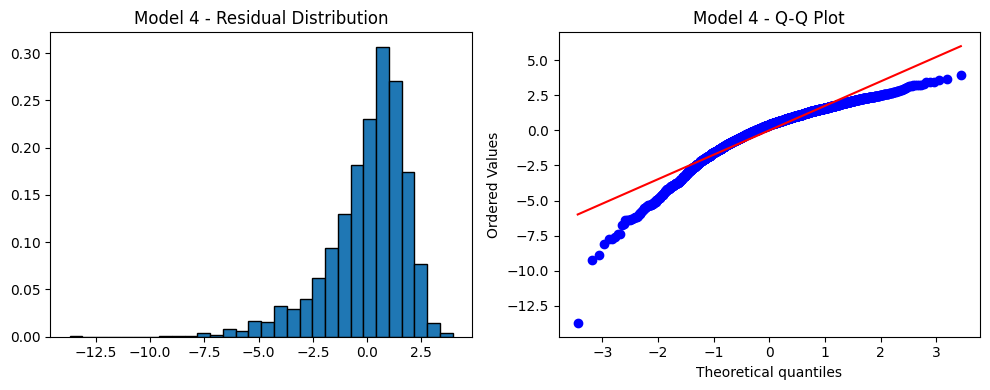


Model 5
--- Statsmodels Parameters ---
[-6.5439595   3.60287318 -0.03954466 -3.15412519]

--- Matrix Method Parameters ---
[-6.5439595   3.60287318 -0.03954466 -3.15412519]

RSS: 17138.0981
Log-Likelihood: -5764.4547
AIC: 11536.9095
BIC: 11560.0424


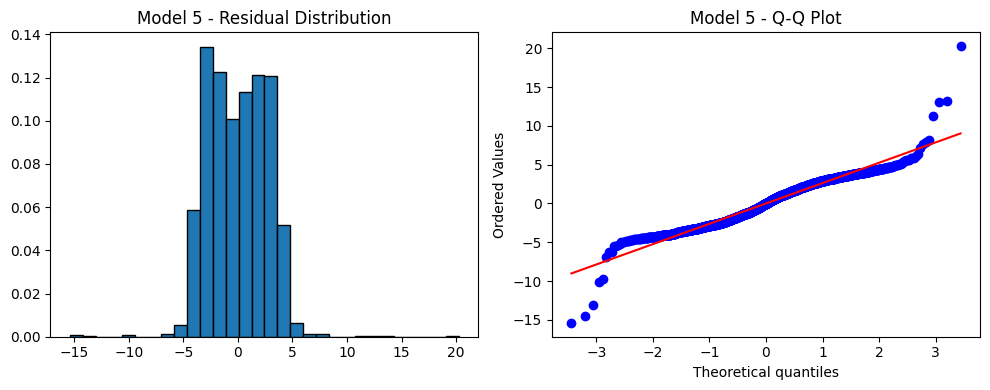

In [ ]:
for model_name, X_df in models.items():
    # 1. Estimate parameters and compute mathematical metrics [5]
    model_residuals = evaluate_model(model_name, X_df, y, n)

    # 2. Plot the error distributions [5]
    plot_residuals(model_name, model_residuals)